<a href="https://colab.research.google.com/github/ceuratfmg2mai/fakereviews/blob/main/03.%20llm_categorizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

Tras seleccionar las reseñas del conjunto de datos de yelp damos inicio a la prueba de la categorización por un modelo LLM, en nuestro caso hemos elegido DeepSeek, ya que el uso de este modelo de IA avanzada se justifica por su potente capacidad de procesamiento del lenguaje natural (PLN).
Este tipo de modelos pueden analizar a fondo el texto de una reseña, detectando patrones lingüísticos, anomalías, inconsistencias y otros indicios sutiles que a menudo distinguen el lenguaje natural y detallado de una experiencia real frente a la artificialidad o generalidad de una reseña fraudulenta.

# Desarrollo del notebook

Lo primero que haremos es la ingesta del conjunto de reseñas (Train/Validation) seleccionadas en el [note book 2](https://github.com/ceuratfmg2mai/fakereviews/blob/main/02.%20categorizar_reviews_human.ipynb) en un RAG y con la técnica "few-shot prompting" instruiremos al modelo de DeepSeek un conjunto de reseñas seleccionadas y categorizadas genunina y falsas, además de la preparación de un prompt muy detallado en el que daremos claras instrucción del como retornar la categorización de las reseñas.

**Nota**: Los dataset están localizados en: *https://drive.google.com/drive/folders/1gNQNt4MHCHT-FiHXVTqz4vfKhgX7jfjY?usp=sharing*

# Librerías

In [7]:
import polars as pl
import pandas as pd
import pyarrow
import sys
import openai
from openai import OpenAI, RateLimitError, APIError
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')
import threading
import seaborn as sns
import time
start_time_global = time.time()
import json
import os
import queue

import httpx
from IPython.display import clear_output
from google.colab import userdata
from google.colab import drive
import uuid
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report


color = '\033[1m\033[38;5;208m'
print(f"{color}Versión pandas: {pd.__version__}")
print(f"{color}Versión polars: {pl.__version__}")
print(f"{color}Versión pyarrow: {pyarrow.__version__}")
print(f"{color}Versión OpenAI: {openai.__version__}")

Versión pandas: 2.2.2
Versión polars: 1.21.0
Versión pyarrow: 18.1.0
Versión OpenAI: 1.81.0


# Inicialización y configuración de variables genéricas

In [8]:
drive.mount('/content/drive', force_remount=True)
explicit_work_path = '/content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/'
print(os.listdir(explicit_work_path))

Mounted at /content/drive
['data_yelp', 'reviews_22052025.arrow', 'reviews_22052025.jsonl', 'reviews_22052025.csv', 'reviews_test.arrow', 'reviews_train_validation.arrow', 'reviews_test.csv', 'reviews_test.jsonl', 'reviews_train_validation.csv', 'reviews_train_validation.jsonl', 'reviews_selected_prompt.arrow', 'reviews_selected_prompt.jsonl']


In [9]:
# Agrega la carpeta fakereviews al syspath del proyecto
if explicit_work_path not in sys.path:
    sys.path.append(explicit_work_path)

## Configuración DeepSeek

In [10]:
# --- 1. Configuración de la API Key y Base URL de DeepSeek ---
try:
    deepseek_api_key = userdata.get('DEEPSEEK_API_KEY')
    deepseek_base_url = 'https://api.deepseek.com/v1'
    deepseek_time_out = 30.0
    print("Clave API y URL base de DeepSeek configuradas correctamente.")
except KeyError:
    print("Error: Las variables de entorno 'DEEPSEEK_API_KEY' o 'DEEPSEEK_BASE_URL' no están configuradas.")

Clave API y URL base de DeepSeek configuradas correctamente.


## Configuración RAG - Qdrant

Para creación de nuestro RAG usaremos QDrant

In [11]:
!pip install -U langchain-community  > /dev/log 2>&1
!pip install -U qdrant-client > /dev/log 2>&1

In [6]:
from importlib import metadata
from langchain_community.embeddings import HuggingFaceEmbeddings
from qdrant_client import QdrantClient, models
print(f"{color}Versión langchain: {metadata.version('langchain')}")
print(f"{color}Versión qdrant_client: {metadata.version('qdrant_client')}")
# 1. Configurar Embeddings
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2") # Generates vector embeddings for each chunk
# Proba el modelo y pedir que genere el vector para la palabra test
# Número de elementos que contiene esa lista.
vector_size_test = len(embedding_model.embed_query("test"))
print(vector_size_test)

Versión langchain: 0.3.25
Versión qdrant_client: 1.14.2


<ipython-input-6-f4c9cffe679f>:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2") # Generates vector embeddings for each chunk
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommende

384


In [7]:
# Nombre de la conlección
COLLECTION_NAME = "tfm2g"
try:
    qdrant_key = userdata.get("QDRANT_KEY")
    qdrant_url = 'https://73e55abe-f0f4-4f08-b30d-c1e2187ebc45.europe-west3-0.gcp.cloud.qdrant.io:6333'
    print("Datos de Qdrant cargados.")
except KeyError:
    print("Error: Las variables de entorno.")
# --- Inicialización del cliente de Qdrant ---
qdrant_cloud_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_key,
    timeout=30
)

Datos de Qdrant cargados.


In [8]:
!wget https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/qdrant_connection.py
from qdrant_connection import QdrantDataIngestor

import sys
if 'qdrant_connection' in sys.modules:
    import importlib
    importlib.reload(sys.modules['qdrant_connection'])
    print("Module qdrant_connection reloaded.")
else:
    print("Module qdrant_connection not found in sys.modules. Reload skipped.")


ingestor = QdrantDataIngestor(
        qdrant_url=qdrant_url,
        qdrant_key=qdrant_key,
        collection_name=COLLECTION_NAME,
        embedding_model=embedding_model,
        vector_size=vector_size_test
    )

--2025-06-01 13:57:29--  https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/qdrant_connection.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18509 (18K) [text/plain]
Saving to: ‘qdrant_connection.py’

qdrant_connection.p 100%[===================>]  18.08K  --.-KB/s    in 0.001s  

2025-06-01 13:57:29 (15.7 MB/s) - ‘qdrant_connection.py’ saved [18509/18509]

Module qdrant_connection reloaded.


In [9]:
!wget https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/review_module.py
from review_module import ReviewFinder
review_finder = ReviewFinder()

--2025-06-01 13:57:31--  https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/review_module.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2988 (2.9K) [text/plain]
Saving to: ‘review_module.py’

review_module.py    100%[===================>]   2.92K  --.-KB/s    in 0s      

2025-06-01 13:57:31 (24.6 MB/s) - ‘review_module.py’ saved [2988/2988]



In [10]:
payload_fields_to_index = {
        "review_id": models.PayloadSchemaType.KEYWORD,
        "user_id": models.PayloadSchemaType.KEYWORD,
        "business_id": models.PayloadSchemaType.KEYWORD,
        "review_count_user": models.PayloadSchemaType.INTEGER,
        "average_stars_user": models.PayloadSchemaType.FLOAT,
        "yelping_days": models.PayloadSchemaType.FLOAT,
        "useful": models.PayloadSchemaType.FLOAT,
        "funny": models.PayloadSchemaType.FLOAT,
        "cool": models.PayloadSchemaType.FLOAT,
        "fans": models.PayloadSchemaType.FLOAT,
        "Cluster": models.PayloadSchemaType.FLOAT
    }

In [11]:
ingestor.setup_collection(payload_fields_to_index=payload_fields_to_index)

Creando colección 'tfm2g' con tamaño de vector 384...
Colección 'tfm2g' creada.
Configurando índices de payload...
Índice de payload creado/verificado para el campo: review_id
Índice de payload creado/verificado para el campo: user_id
Índice de payload creado/verificado para el campo: business_id
Índice de payload creado/verificado para el campo: review_count_user
Índice de payload creado/verificado para el campo: average_stars_user
Índice de payload creado/verificado para el campo: yelping_days
Índice de payload creado/verificado para el campo: useful
Índice de payload creado/verificado para el campo: funny
Índice de payload creado/verificado para el campo: cool
Índice de payload creado/verificado para el campo: fans
Índice de payload creado/verificado para el campo: Cluster
Configuración de la colección completada.


## Lectura del fichero de las reseñas a evaluar por el modelo.

En este apartado, leeremos con Polars el conjunto completo de los datos seleccionados.

In [10]:
# Lectura del fichero de las reseñas seleccionadas train y validation
review_selected_file_path = f'{explicit_work_path}reviews_train_validation.jsonl'
df_data_train_validate = pl.read_ndjson(review_selected_file_path)
print(f"\nTotal de reseñas a procesar: {df_data_train_validate.shape[0]}")


Total de reseñas a procesar: 1750


In [11]:
# Lectura del fichero de las reseñas seleccionadas test
review_selected_file_path = f'{explicit_work_path}reviews_test.jsonl'
df_data_test = pl.read_ndjson(review_selected_file_path)
print(f"\nTotal de reseñas a procesar: {df_data_train_validate.shape[0]}")


Total de reseñas a procesar: 1750


## Envío del conjunto de datos Train a Qdrant

In [12]:
# Convertir el DataFrame de Polars a Pandas para usar train_test_split
df_data_train_validate_pd = df_data_train_validate.to_pandas()

# Definir el tamaño del conjunto de validación (por ejemplo, 2%)
validation_size = 0.2

# Separar el conjunto de datos en entrenamiento y validación
# Usamos random_state=42 para reproducibilidad
df_train_pd, df_validate_pd = train_test_split(
    df_data_train_validate_pd,
    test_size=validation_size,
    random_state=42
)

# Opcionalmente, convertir de nuevo a DataFrames de Polars si lo necesitas
df_train = pl.from_pandas(df_train_pd)
df_validate = pl.from_pandas(df_validate_pd)

# Imprimir el tamaño de los nuevos conjuntos para verificar
print("Tamaño del conjunto de entrenamiento:", df_train.shape[0])
print("Tamaño del conjunto de validación:", df_validate.shape[0])

Tamaño del conjunto de entrenamiento: 1400
Tamaño del conjunto de validación: 350


In [15]:
ingestor.ingest_dataframe(df_train)


Iniciando ingestión de 1400 filas en la colección 'tfm2g'...
Lote 1/6 (filas aprox. 1-256) enviado. 256 puntos.
Lote 2/6 (filas aprox. 257-512) enviado. 256 puntos.
Lote 3/6 (filas aprox. 513-768) enviado. 256 puntos.
Lote 4/6 (filas aprox. 769-1024) enviado. 256 puntos.
Lote 5/6 (filas aprox. 1025-1280) enviado. 256 puntos.
Progreso: 1280/1400 filas procesadas. Tiempo total: 79.57 seg.
Lote 6/6 (filas aprox. 1281-1400) enviado. 120 puntos.
Progreso: 1400/1400 filas procesadas. Tiempo total: 84.74 seg.

Ingestión completada para 1400 filas.
Tiempo total de ingestión: 84.74 segundos.
Todos los lotes fueron procesados sin errores reportados por el cliente.


Realizamos la verficación de la inserción

In [16]:
ingestor.verify_ingestion(original_id_to_check = '_9fLdvi5DtnYPb41_t5x8A')


--- Verificación de Datos Insertados ---
Número total de puntos en la colección 'tfm2g': 1400
Intentando recuperar la reseña con 'review_id' (en payload) igual a: '_9fLdvi5DtnYPb41_t5x8A'
Punto encontrado por 'review_id' en payload.

--- Detalles del Punto de Muestra ---
  ID de Qdrant (UUID generado): 3e82970b-ff95-47c4-9621-03f93e45f744
  Payload:
    review_id: _9fLdvi5DtnYPb41_t5x8A
    review: Clean large spot with amazing service. Used to live in Tampa back in college and definitely wish this place was around back then. Highly recommend
    user_id: S62eAfSX9kSfdNwwIuAfJg
    business_id: QgaHfznufIXLm8WfoBImIg
    review_count_user: 5
    average_stars_user: 3.4
    yelping_days: 4529.0
    useful: 9.0
    funny: 0.0
    cool: 0.0
    fans: 1.0
    Cluster: 1


In [13]:
ingestor.get_classification_by_review_id(review_id = '_9fLdvi5DtnYPb41_t5x8A')

1

In [14]:
review = "I'd love to give a 3 1/2 Star. Really pleasant staff, very accommodating and friendly.  Food was good."
print(ingestor.get_review_by_text(review_text = review))

{'Fake': [{'review_id': '0eOqsURU5iqGeCsJWggZOg', 'review': 'Good place to drink cheap beer and listen to the locals talk about the good old days when it was legal to beat your wife. They have ample boat parking which is nice. Bartenders are very willing and NASCAR is always on the tube. If you do go please tip the help, cause shit man, their job sucks.', 'user_id': 'wWhZhZ5OR0RMFIKTkIe3Hw', 'business_id': 'HYuLJ_8FXQgOykbG1dd4ew', 'review_count_user': 131, 'average_stars_user': 3.93, 'yelping_days': 3618.0, 'useful': 101.0, 'funny': 66.0, 'cool': 58.0, 'fans': 2.0, 'Cluster': 0}, {'review_id': '8--xj_c01WTUnOUUKi7vNg', 'review': "This is the best McDonald's I have ever been to. Employees were happy to assist customers and extremely polite and welcoming! A great experience all around.", 'user_id': 'A9r8L-9-B62_21-_n97c-w', 'business_id': 'WXVb0_TPSNGjqRshykMY8Q', 'review_count_user': 5, 'average_stars_user': 3.2, 'yelping_days': 3699.0, 'useful': 3.0, 'funny': 0.0, 'cool': 0.0, 'fans':

# Evaluación de categorización de las reseñas por DeepSeek

Tras almancenar las reseñas del conjunto de train en el RAG de Qdrant, procedemos a la creación de los prompts.

## 1 - Defnimos el comportamiento del prompt con la técnica de few-shot prompting.

Este primer prompt define la plantilla para estructurar y enviar al modelo los datos detallados de cada reseña (incluyendo texto, valoraciones, metadatos del usuario y categoría de la review 'Cluster'), los cuales se presentan como ejemplos de un tipo ({{type}}) (Fake o Genuine) específico.  Finalmente este promt será utilizado como complemento del prompt principal.

In [37]:
example_base_review_template = f"""

        Example {{type}} Review Text: {{review_text}}
        Example {{type}} User Review Count: {{review_count_user}}
        Example {{type}} User Avg Stars: {{average_stars_user}}
        Example {{type}} User Yelping Days: {{yelping_days}}
        Example {{type}} Review Useful Votes: {{useful}}
        Example {{type}} Review Funny Votes: {{funny}}
        Example {{type}} Review Cool Votes: {{cool}}
        Example {{type}} User Fan Count: {{fans}}
        Example {{type}} Classification: {{Cluster}}

        """
# Modificamos la plantilla para usar llaves simples para .format()
example_base_review_template = example_base_review_template.replace("{{", "{").replace("}}", "}")

In [38]:
review_test_prompt = f"""
- Input Review Text: {{text}}
- Input User Review Count: {{review_count_user}}
- Input User Avg Stars: {{average_stars_user}}
- Input User Yelping Days: {{yelping_days}}
- Input Review Useful Votes: {{useful}}
- Input Review Funny Votes: {{funny}}
- Input Review Cool Votes: {{cool}}
- Input User Fan Count: {{fans}}
"""
review_test_prompt = review_test_prompt.replace("{{", "{").replace("}}", "}")

A continuación, el prompt principal, encargado de guiar al modelo DeepSeek para categorizar cada reseña como 'Genuina' o 'Falsa', además, Proporciona un conjunto detallado de instrucciones que especifican: la tarea de clasificación, los criterios para cada categoría, incorporan los ejemplos a través de la variable {{reviews_examples_with_metadata}} y la reseña a categorizar con el prompt {{review_test_prompt}}.

In [39]:
base_prompt_template = f"""
* Task: Classify the customer review provided at the end into a single category: Genuine or Fake, considering the review text AND associated metadata.

* Metadata Provided (for the review to be classified and for each example):
- Review Text: The content of the review.
- User Review Count: Total number of reviews written by this user.
- User Avg Stars: The average rating given by this user across all their reviews.
- User Yelping Days: Number of days the user has been active on Yelp.
- Review Useful Votes: Count of 'useful' votes for this review.
- Review Funny Votes: Count of 'funny' votes for this review.
- Review Cool Votes: Count of 'cool' votes for this review.
- User Fan Count: Number of fans this user has.
- Classification: Is a single category Cluster=1 means 'Genuine' and Cluster=0 means 'Fake'.

* Category Definitions:
- Genuine: The review appears to be from a real customer with an authentic experience. Details in text are often plausible and consistent with metadata patterns (e.g., user has some review history, rating aligns somewhat with user averages unless specific reasons given in text).
- Fake: The review appears artificial, possibly promotional or defamatory. May show metadata inconsistencies (e.g., user with very few reviews + extreme generic rating, rating wildly different from user average without clear textual explanation). Text details (or lack thereof) are primary, but metadata provides important context.

* Examples of Classification (including metadata):
(Note: In the following examples, the 'Classification' ('Genuine' or 'Fake') is determined by an internal 'Cluster' field, where Cluster=1 means 'Genuine' and Cluster=0 means 'Fake'. Each example will present its metadata as listed above, followed by its known Classification.)
--- START EXAMPLES ---
{{reviews_examples_with_metadata}}
--- END EXAMPLES ---

* Now, classify the following review using its text and metadata:
---start Input ---
{{review_test}}
---end Input ---
* Output Instructions: Return ONLY the unique value for category '1' for Genuine or '0' for Fake and nothing else.
"""
# Modificamos la plantilla para usar llaves simples para .format()
base_prompt_template = base_prompt_template.replace("{{", "{").replace("}}", "}")

## 2 - Creación de los prompts para cada subconjunto de datos


Creación del prompt para el subconjunto de Test

In [40]:
prompts_data = []
for row in df_data_test.iter_rows(named=True):
    prompt = review_finder.build_test_prompt_from(row, review_test_prompt)
    prompts_data.append({
        "review_id": row.get("review_id", ""),
        "Cluster": row.get("Cluster", ""),
        "review_test": prompt
    })

df_prompts = pl.DataFrame(prompts_data)

A continuación, crearemos el prompt de ejemplo apartir del subconjunto de evaluación, el texto de cada reseña de evaluación se emplea como consulta para buscar y extraer información relevante del RAG. Esta información extraída del RAG (y solo esta) se agrupa para constituir el prompt final.

Dato que el conjunto de Test es mejor que el conjunto de datos de evalución, realizaremos una selección "aleatoria" de reseñas del dataset de Evaluation pero igual en cantidad al dataset de Test.

In [41]:
#Extracción del texto de alguna reseñas del dataset de evalución
df_random_text = df_train.sample(n=len(df_data_test), seed=42).select(pl.col('text'))
#agregar el resultado al df de prompts
df_prompts = df_prompts.with_columns(df_random_text['text'])

In [42]:
# Lista de columnas necesarias para la plantilla del prompt
columns_needed_prompt = [
    "text","review_test"
]

A continuación, es la creación del prompt principal para cada una de las reseñas del dataset seleccionado.

In [43]:
start_time=time.time()
try:
    df_data_reviews_selected_pl = df_prompts.with_columns(
        # Crea un struct (como un objeto temporal por fila) con las columnas necesarias
        pl.struct([pl.col(c) for c in columns_needed_prompt])
        # Aplica la función de formateo a cada struct
        .map_elements(
            lambda row_struct: review_finder.format_principal_prompt_for(row_struct, ingestor, example_base_review_template, base_prompt_template),
            return_dtype=pl.Utf8  # Especifica que la función devuelve strings
        )
        # Dale un nombre a la nueva columna resultante
        .alias("prompt_completo"),
        pl.col('review_id').alias('review_id'),
        pl.col('Cluster').alias('Cluster')
    )
    pl.Config.set_fmt_str_lengths(200) # Aumenta el ancho para ver mejor el prompt

    # Imprime solo la nueva columna para verificar una fila
    print("\nEjemplo de la primera fila de la columna 'prompt_completo':")
    print(df_data_reviews_selected_pl.row(0, named=True)['prompt_completo'])
except Exception as e:
    print(f"An error occurred: {e}")
else:
    print("-" * 50 + "\n")
    print(f"La operación fue exitosa en {time.time()-start_time:.2f}seg")


Ejemplo de la primera fila de la columna 'prompt_completo':

* Task: Classify the customer review provided at the end into a single category: Genuine or Fake, considering the review text AND associated metadata.

* Metadata Provided (for the review to be classified and for each example):
- Review Text: The content of the review.
- User Review Count: Total number of reviews written by this user.
- User Avg Stars: The average rating given by this user across all their reviews.
- User Yelping Days: Number of days the user has been active on Yelp.
- Review Useful Votes: Count of 'useful' votes for this review.
- Review Funny Votes: Count of 'funny' votes for this review.
- Review Cool Votes: Count of 'cool' votes for this review.
- User Fan Count: Number of fans this user has.
- Classification: Is a single category Cluster=1 means 'Genuine' and Cluster=0 means 'Fake'.

* Category Definitions:
- Genuine: The review appears to be from a real customer with an authentic experience. Details in

In [44]:
columns_to_keep = ['review_id', 'Cluster', 'prompt_completo']
df_data_reviews_selected_pl = df_data_reviews_selected_pl.select(columns_to_keep)
df_data_reviews_selected_pl = df_data_reviews_selected_pl.rename({"Cluster": "Cluster_Human"})

df_data_reviews_selected_pl.head(1)

review_id,Cluster_Human,prompt_completo
str,i64,str
"""x8jX1ffVg5VNrFQFsRnDTA""",1,""" * Task: Classify the customer review provided at the end into a single category: Genuine or Fake, considering the review text AND associated metadata. * Metadata Provided (for the review to be class…"


In [45]:
# --Opcional -- Guardar como Arrow IPC
try:
    review_selected_file_path = f'{explicit_work_path}reviews_selected_prompt.arrow'
    df_data_reviews_selected_pl.write_ipc(review_selected_file_path, compression='zstd')
except Exception as e:
    print(f"Error al guardar IPC: {e}")
else:
    print('Fichero seleccionados guardado en IPC')

Fichero seleccionados guardado en IPC


In [46]:
try:
    review_selected_file_path = f'{explicit_work_path}reviews_selected_prompt.jsonl'
    df_data_reviews_selected_pl.write_json(review_selected_file_path)
except Exception as e:
    print(f"Error al guardar jsonl: {e}")
else:
    print('Fichero seleccionados guardado en JSONL')

Fichero seleccionados guardado en JSONL


## 3 - Punto de control
En este punto leemos el fichero guardamos del dataset seleccionado junto con el prompt de cada reseña.

In [12]:
# En caso de error debe volver a iniciar desde la lectura.
try:
    review_selected_file_path = f'{explicit_work_path}reviews_selected_prompt.arrow'
    df_data_reviews_selected_pl = pl.read_ipc(review_selected_file_path, memory_map=False)
    print("¡Archivo de reseñas con prompt leido!")
    # Muestra las primeras filas y la información del DataFrame
    print(df_data_reviews_selected_pl.head(1))
    print(df_data_reviews_selected_pl.shape)
    print(df_data_reviews_selected_pl.schema)

except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta: {review_selected_file_path}")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo con Polars: {e}")

¡Archivo de reseñas con prompt leido!
shape: (1, 3)
┌────────────────────────┬───────────────┬────────────────────────────────┐
│ review_id              ┆ Cluster_Human ┆ prompt_completo                │
│ ---                    ┆ ---           ┆ ---                            │
│ str                    ┆ i64           ┆ str                            │
╞════════════════════════╪═══════════════╪════════════════════════════════╡
│ x8jX1ffVg5VNrFQFsRnDTA ┆ 1             ┆                                │
│                        ┆               ┆ * Task: Classify the customer… │
└────────────────────────┴───────────────┴────────────────────────────────┘
(200, 3)
Schema([('review_id', String), ('Cluster_Human', Int64), ('prompt_completo', String)])


## 4 - Función control de re-ejecución de categorización
A continuación, una función para controlar la ultima ejecución del dataset y no iniciar desde el principio.

In [13]:
# Lógica para reanudar el procesamiento
# Función para leer índices procesados
def get_processed_indices(temp_file_path: str) -> set[int]:
    """
    Lee el archivo temporal JSON Lines y devuelve un conjunto de índices
    de reseñas que ya han sido procesadas.

    Args:
        temp_file_path: La ruta al archivo temporal JSON Lines.

    Returns:
        Un conjunto de enteros representando los índices procesados.
    """
    processed_indices = set()
    if os.path.exists(temp_file_path):
        print(f"\nArchivo temporal '{temp_file_path}' encontrado. Leyendo índices procesados...")
        try:
            with open(temp_file_path, 'r', encoding='utf8') as f:
                for line_num, line in enumerate(f):
                    line = line.strip()
                    if not line: # Saltar líneas vacías
                        continue
                    try:
                        data = json.loads(line)
                        # Asumimos que el índice se guarda bajo la clave 'index'
                        if 'review_id' in data:
                            processed_indices.add(data['review_id'])
                        else:
                             print(f"Advertencia: Línea {line_num + 1} en '{temp_file_path}' no contiene un índice válido.")
                    except json.JSONDecodeError:
                        print(f"Advertencia: Ignorando línea no válida/incompleta en el archivo temporal (línea {line_num + 1}).")
                        # Si la decodificación falla, asumimos que es una línea parcial al final
                        break # Detener la lectura aquí
            print(f"Encontrados {len(processed_indices)} reseñas procesadas anteriormente.")
        except Exception as e:
            print(f"Error al leer el archivo temporal '{temp_file_path}': {e}")
            print("Se procesarán todas las reseñas desde el inicio por precaución.")
            processed_indices = set() # Si hay un error de lectura, empezar de cero
    else:
        print(f"\nArchivo temporal '{temp_file_path}' no encontrado. Iniciando procesamiento desde el inicio.")

    return processed_indices

# Archivos de salida de las reseñas categorizadas
reviews_categorize_output_file = f'{explicit_work_path}final_reviews_categorize.jsonl'

# Obtener los índices ya procesados llamando a la nueva función
processed_indices = get_processed_indices(reviews_categorize_output_file)


Archivo temporal '/content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/final_reviews_categorize.jsonl' no encontrado. Iniciando procesamiento desde el inicio.


## 5 - Creación del cliente o conexión con DeepSeek.
A continuación, haremos la conexión y la definición de variables claves para resolver la categoría de la reseña.

In [14]:
# modelo de DeepSeek para tareas
MODEL_NAME = "deepseek-chat"
print('Inicia procesamiento de los datos en DeepSeek')
# --- Configurar el cliente de OpenAI para usar el endpoint de DeepSeek ---
client = OpenAI(
    base_url=deepseek_base_url,
    api_key=deepseek_api_key,
    timeout=httpx.Timeout(deepseek_time_out, connect=5.0)
)

# Variables claves
# Crear Colas
tasks_to_do = queue.Queue()
results_done = queue.Queue()

Inicia procesamiento de los datos en DeepSeek


## 6 - Creación de workers para la conexión
Para resolver más rapidamente la categorización de las reseñas hacemos conexión con hilos, para ello creamos la siguiente función.

In [15]:
# --- Función del Trabajador (Worker) ---
# Esta función será ejecutada por cada hilo.
# Toma tareas de una cola, las procesa (llama a la API) y pone resultados en otra cola.

def worker(task_queue: queue.Queue, result_queue: queue.Queue, worker_id):
    """
        Procesa reseñas de la cola de tareas y pone resultados en la cola de resultados.
        Args:
            task_queue: Contiene el id de la reseña y el prompt.
            result_queue: Contendrá la salida de cada una de las evaluaciones.
            worker_id: Id unico para controlar los hilos.

    """

    print(f"[Worker {worker_id}] Iniciado.")
    while True:
        start_time=time.time()
        task_data = task_queue.get()
        if task_data is None:
            task_queue.task_done()
            break

        review_id = task_data.get('review_id', 'ID_DESCONOCIDO')
        final_prompt = task_data.get('prompt_completo', None)
        if not final_prompt:
            print(f"[Worker {worker_id}] ERROR: Falta la clave en los datos para {review_id}. Omitiendo.")
            result_data = {"review_id": review_id, "status": "missing_data_error", "classification": "None"}
            result_queue.put(result_data)
            task_queue.task_done()
            continue # Pasar a la siguiente tarea

        # Preparar datos para resultado
        result_data = {"review_id": review_id}


        try:

            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[{"role": "system", "content": final_prompt}],
                max_tokens=2,  # Solo necesitamos 'Genuine' 1 o 'Fake' 0
                temperature=0.1, # Muy baja para clasificación directa
                n=1,
                stop=None
            )
            evaluation = response.choices[0].message.content.strip()

            # Validar la salida (opcional pero recomendado)
            if int(evaluation) <= 1:
                 result_data.update({"status": "success", "classification": evaluation})
            else:
                 print(f"[Worker {worker_id}] WARN: Salida inesperada para {review_id}: '{evaluation}'. Marcando como error.")
                 result_data.update({"status": "invalid_output", "classification": "None"})

        except RateLimitError:
            print(f"[Worker {worker_id}] WARN: Rate Limit en {review_id}. Re-encolando...")
            task_queue.put(task_data) # Re-encolar la tarea (diccionario)
            time.sleep(20 + worker_id * 2)
            result_data.update({"status": "rate_limit_error", "details": "Tarea re-encolada"})
        except APIError as e:
            print(f"[Worker {worker_id}] ERROR API en {review_id}: {e}")
            result_data.update({"status": "api_error", "details": str(e)})
            print(f"Tipo de error: {type(e).__name__}") # Nombre de la clase de la excepción
        except Exception as e:
            print(f"[Worker {worker_id}] ERROR Inesperado en {review_id}: {e}")
            result_data.update({"status": "unexpected_error", "details": str(e)})
        else:
          # clear_output(wait=True)
          print(f'[Worker {worker_id}] Terminado. Total tiempo ejecución: {time.time() - start_time:.2f}')
        finally:
             result_queue.put(result_data)
             task_queue.task_done()


## 7 - Creación de función para almacenar resultados
Con el objetivo de ir guardando los resultados de la evaluaciónd de cada reseña, la siguiente función los guardará según cada hilo vaya terminando.

In [16]:
def result_writer(result_queue, filename, mode='a'):
    print(f"[Writer] Iniciado. Escribiendo resultados en {filename} (modo: '{mode}')")
    count = 0
    processed_in_session = 0
    try:
        with open(filename, mode, encoding='utf-8') as f:
            while True:
                result_data = result_queue.get()
                if result_data is None:
                    result_queue.task_done()
                    break
                try:
                    json_line = json.dumps(result_data, ensure_ascii=False)
                    f.write(json_line + '\n')
                    f.flush()
                    processed_in_session += 1
                    if processed_in_session % 100 == 0:
                        print(f"[Writer] {processed_in_session} nuevos resultados escritos en esta sesión.")
                except Exception as e:
                    print(f"[Writer] ERROR escribiendo resultado para {result_data.get('review_id', 'ID_DESCONOCIDO')}: {e}")
                finally:
                    result_queue.task_done()
    except IOError as e:
         print(f"[Writer] ERROR al abrir/escribir el archivo {filename}: {e}")
    else:
      #clear_output(wait=True)
      print(f"[Writer] Señal de parada recibida. Total escritos en esta sesión: {processed_in_session}. Terminando.")

## 8 - Creación de hilo escritor del resultado de las reseñas

In [17]:
# 4. Iniciar Hilo Escritor (igual, pasando modo)
print(f"Iniciando hilo escritor para guardar en {reviews_categorize_output_file}...")
writer_thread = threading.Thread(target=result_writer, args=(results_done, reviews_categorize_output_file), daemon=True)
writer_thread.start()

Iniciando hilo escritor para guardar en /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/final_reviews_categorize.jsonl...
[Writer] Iniciado. Escribiendo resultados en /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/final_reviews_categorize.jsonl (modo: 'a')


## 9 - Cargar los prompts en la cola de procesamiento.

Para realización la ejecución por hilos son agregados a una cola de procesamiento.

In [18]:
# Selección de las columnas de trabajo.
required_columns = ['review_id', 'prompt_completo']

# 5. Llenar la cola de tareas (MODIFICADO para enviar diccionarios)
print(f"Llenando la cola con tareas desde el DataFrame ({len(df_data_reviews_selected_pl)} filas).")
tasks_added_this_session = 0
# Seleccionar todas las columnas necesarias y convertir a diccionarios
for task_dict in df_data_reviews_selected_pl.select(required_columns).iter_rows(named=True):
    review_id = task_dict['review_id']
    if review_id not in processed_indices:
        tasks_to_do.put(task_dict) # Poner el diccionario entero en la cola
        tasks_added_this_session += 1

print(f"Cola de tareas llena con {tasks_added_this_session} nuevas tareas (se omitieron {len(processed_indices)} encontradas en el archivo).")

# Control para finalizar los hilos.
if tasks_added_this_session == 0:
    print("No hay nuevas reseñas para procesar.")
    results_done.put(None)
    writer_thread.join()
    print("Proceso finalizado.")
    exit()

Llenando la cola con tareas desde el DataFrame (200 filas).
Cola de tareas llena con 200 nuevas tareas (se omitieron 0 encontradas en el archivo).


## 10 -  Definición de los hilos

En este apartado damos inicio a la ejecución de cada uno de los hilos.

In [19]:
NUM_THREADS = 5
threads = []
print(f"Creando e iniciando {NUM_THREADS} hilos trabajadores.")
for i in range(NUM_THREADS):
    # Pasar la plantilla base como argumento al worker
    t = threading.Thread(target=worker, args=(tasks_to_do, results_done, i + 1), daemon=True)
    t.start()
    threads.append(t)
print(f"Hilos trabajadores iniciados, total {len(threads)}")

Creando e iniciando 5 hilos trabajadores.
[Worker 1] Iniciado.
[Worker 2] Iniciado.
[Worker 3] Iniciado.
[Worker 4] Iniciado.
[Worker 5] Iniciado.
Hilos trabajadores iniciados, total 5


## 11 - Finalización y registro del resultado de cada uno de los hilos

Este apartado controla la finalización de cada hilo y guarda los resultados.

In [20]:
# Esperar a las tareas
print("Esperando a que todas las tareas nuevas sean procesadas...")
tasks_to_do.join()
print("Todas las tareas nuevas han sido procesadas por los workers.")

# Enviar señales stop a workers
print("Enviando señales de parada (None) a los workers...")
for _ in range(NUM_THREADS):
    tasks_to_do.put(None)

# Esperar a workers
print("Esperando a que los hilos trabajadores terminen...")
for t in threads:
    t.join()
print("Todos los hilos trabajadores han terminado.")

# Enviar señal stop al escritor
print("Enviando señal de parada (None) al hilo escritor...")
results_done.put(None)

# Esperar al escritor
print("Esperando a que el hilo escritor termine...")
writer_thread.join()
print("Hilo escritor terminado.")

print(f"\nProcesamiento completado. Los resultados actualizados están en {reviews_categorize_output_file}")

Esperando a que todas las tareas nuevas sean procesadas...
[Worker 5] Terminado. Total tiempo ejecución: 4.25
[Worker 3] Terminado. Total tiempo ejecución: 4.64
[Worker 4] Terminado. Total tiempo ejecución: 4.70
[Worker 2] Terminado. Total tiempo ejecución: 4.78
[Worker 1] Terminado. Total tiempo ejecución: 5.20
[Worker 5] Terminado. Total tiempo ejecución: 3.90
[Worker 3] Terminado. Total tiempo ejecución: 4.05
[Worker 2] Terminado. Total tiempo ejecución: 4.28
[Worker 4] Terminado. Total tiempo ejecución: 4.39
[Worker 1] Terminado. Total tiempo ejecución: 4.10
[Worker 3] Terminado. Total tiempo ejecución: 3.95
[Worker 1] Terminado. Total tiempo ejecución: 5.38
[Worker 2] Terminado. Total tiempo ejecución: 5.71
[Worker 4] Terminado. Total tiempo ejecución: 5.96
[Worker 3] Terminado. Total tiempo ejecución: 3.91
[Worker 2] Terminado. Total tiempo ejecución: 3.97
[Worker 5] Terminado. Total tiempo ejecución: 10.97
[Worker 1] Terminado. Total tiempo ejecución: 5.88
[Worker 4] Terminado. 

# Visualización de la evaluación
A continuación, detallamos visualmente el resultado obtenido de la categorización realizada por DeepSeek.

In [21]:
# Lectura del fichero de las reseñas seleccionadas de yelp
review_categorice_file_path = f'{explicit_work_path}final_reviews_categorize.jsonl'
df_data_reviews_categorice_pl = pl.read_ndjson(review_categorice_file_path)
print(f"\nTotal de reseñas categorizadas: {df_data_reviews_categorice_pl.shape[0]}")


Total de reseñas categorizadas: 200


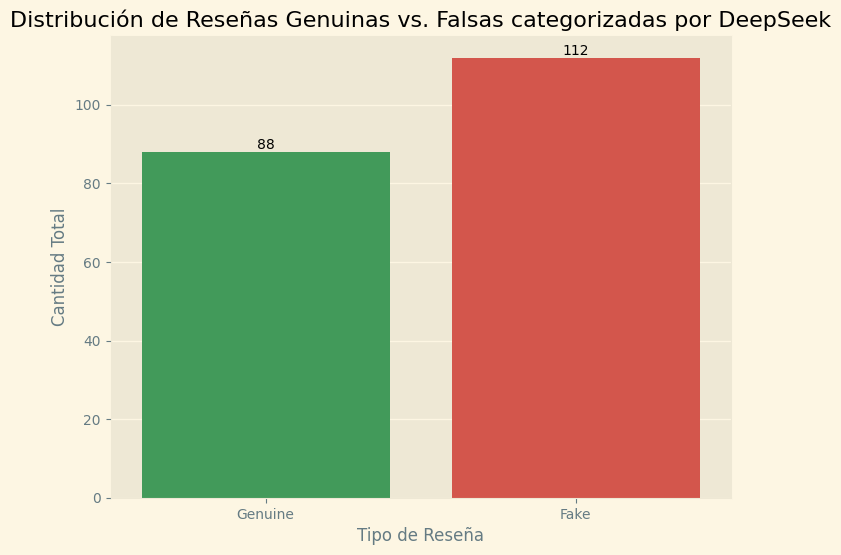

In [32]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_data_reviews_categorice_pl.with_columns(
    pl.col('classification').replace({0: 'Fake', 1: 'Genuine'})
)['classification'].value_counts().to_pandas()

color_map = {'Genuine': '#34A853', 'Fake': '#EA4335'}
# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='classification', y='count', data=df_counts, palette=color_map, hue='classification')

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas categorizadas por DeepSeek', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',           # Texto a mostrar (la altura de la barra como entero)
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posición (x, y) para el texto
                ha='center',                       # Alineación horizontal
                va='center',                       # Alineación vertical
                xytext=(0, 5),                    # Desplazamiento del texto (en puntos): 0 horizontal, 5 vertical (encima de la barra)
                textcoords='offset points',        # Usar coordenadas de desplazamiento
                fontsize=10)                       # Tamaño de la fuente para la anotación

plt.show()


# Conclusión

In [36]:
# Seleccionar solo las columnas necesarias de cada DataFrame
df_categorized = df_data_reviews_categorice_pl.select(['review_id', 'classification'])
df_selected = df_data_reviews_selected_pl.select(['review_id', 'Cluster_Human'])

# Realizar la unión (merge) de los dos DataFrames en base a 'review_id'
# Un inner join es apropiado si solo quieres las reseñas que están en ambos DataFrames
df_combined = df_selected.join(df_categorized, on='review_id', how='inner')

# Renombrar la columna 'classification' a 'Cluster_IA'
df_combined = df_combined.rename({'classification': 'Cluster_IA'})

# Mostrar las primeras filas y el esquema del DataFrame combinado
print("DataFrame combinado con las columnas seleccionadas:")
print(df_combined.head())

DataFrame combinado con las columnas seleccionadas:
shape: (5, 3)
┌────────────────────────┬───────────────┬────────────┐
│ review_id              ┆ Cluster_Human ┆ Cluster_IA │
│ ---                    ┆ ---           ┆ ---        │
│ str                    ┆ i64           ┆ str        │
╞════════════════════════╪═══════════════╪════════════╡
│ EgCuHwVTJCjYTfOqg1GVtw ┆ 0             ┆ 1          │
│ jMUjEVjkQZZ_LZIhiswehA ┆ 0             ┆ 0          │
│ ZpjCRt5lFM3Xeep2jXXWkg ┆ 1             ┆ 0          │
│ TBtvWeMYqisouUSoE5-wRA ┆ 0             ┆ 0          │
│ x8jX1ffVg5VNrFQFsRnDTA ┆ 1             ┆ 1          │
└────────────────────────┴───────────────┴────────────┘


## Accuracy

In [39]:
cluster_human_values = df_combined['Cluster_Human'].to_numpy()
cluster_ia_values = df_combined['Cluster_IA'].to_numpy()
cluster_ia_values = cluster_ia_values.astype(int)
accuracy = accuracy_score(cluster_human_values, cluster_ia_values)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7050


## Precision, Recall y F1-score

In [41]:
precision = precision_score(cluster_human_values, cluster_ia_values, pos_label=1)
recall = recall_score(cluster_human_values, cluster_ia_values, pos_label=1)
f1 = f1_score(cluster_human_values, cluster_ia_values, pos_label=1)

print(f"Precision (clase 1 - Genuine): {precision:.4f}")
print(f"Recall (clase 1 - Genuine): {recall:.4f}")
print(f"F1-Score (clase 1 - Genuine): {f1:.4f}")

Precision (clase 1 - Genuine): 0.4205
Recall (clase 1 - Genuine): 0.8222
F1-Score (clase 1 - Genuine): 0.5564


## Matriz de Confusión (para un desglose detallado)

In [43]:
cm = confusion_matrix(cluster_human_values, cluster_ia_values)
print("\nMatriz de Confusión:")
print(cm)
# La salida es:
# [[TN, FP],
#  [FN, VP]]
# En este ejemplo:
# TN (0,0): 3 (AI predijo 0, humano 0)
# FP (0,1): 2 (AI predijo 1, humano 0)
# FN (1,0): 1 (AI predijo 0, humano 1)
# VP (1,1): 4 (AI predijo 1, humano 1)
#                       Predicciones de la IA
#                     -------------------------
#                     | Predijo Fake | Predijo Genuine |
# --------------------|--------------|-----------------|
# Realidad (Humano)   |              |                 |
# Clase: Fake         |     TN       |       FP        |
#                     |    104       |       51        |
# --------------------|--------------|-----------------|
# Realidad (Humano)   |              |                 |
# Clase: Genuine      |     FN       |       TP        |
#                     |      8       |       37        |
# --------------------|--------------|-----------------|


Matriz de Confusión:
[[104  51]
 [  8  37]]


## Reporte de Clasificación (resumen completo)

In [45]:
print("\nReporte de Clasificación:")
print(classification_report(cluster_human_values, cluster_ia_values, target_names=['Fake', 'Genuine']))


Reporte de Clasificación:
              precision    recall  f1-score   support

        Fake       0.93      0.67      0.78       155
     Genuine       0.42      0.82      0.56        45

    accuracy                           0.70       200
   macro avg       0.67      0.75      0.67       200
weighted avg       0.81      0.70      0.73       200



El modelo de clasificación de reseñas en 'Genuinas' o 'Falsas', implementado mediante el Large Language Model (LLM) DeepSeek, alcanzó una exactitud (accuracy) global del 70% sobre el conjunto de datos de evaluación.

Los resultados indican una notable fortaleza del modelo DeepSeek en la identificación precisa de reseñas consideradas 'Falsas', con una precisión del 93%. Asimismo, el sistema demuestra una buena capacidad para detectar la mayoría de las reseñas que son auténticamente 'Genuinas', logrando un recall del 82% para esta clase.

No obstante, el principal desafío y área de mejora identificada para este enfoque basado en DeepSeek reside en la precisión para la clase 'Genuina', que se sitúa en un 42%. Esto implica que una proporción considerable de reseñas 'Falsas' son erróneamente clasificadas como 'Genuinas' (falsos positivos). Este es un aspecto particularmente sensible al analizar el rendimiento, considerando que el desbalance observado en el conjunto de evaluación utilizado (155 instancias 'Falsas' frente a solo 45 'Genuinas') —una distribución que, según se considera, pudo ser influenciada por el propio proceso de selección y etiquetado humano— magnifica el impacto de los errores en la clase minoritaria.

En definitiva, si bien la aplicación de DeepSeek presenta una base prometedora para esta tarea, futuras iteraciones deberían centrarse en estrategias para mejorar la discriminación de la clase 'Genuina'. El objetivo sería reducir la tasa de falsos positivos y robustecer así la fiabilidad general del clasificador, especialmente al evaluar su desempeño sobre la clase minoritaria en contextos como el presentado en este conjunto de evaluación.